Розмірність датасету: (891, 12)
Найкращі параметри: {'max_depth': 7, 'n_estimators': 100}
Точність на крос-валідації: 82.72%
Accuracy  (Точність) : 85.47%
Precision (Влучність): 82.43%
Recall    (Повнота)  : 82.43%


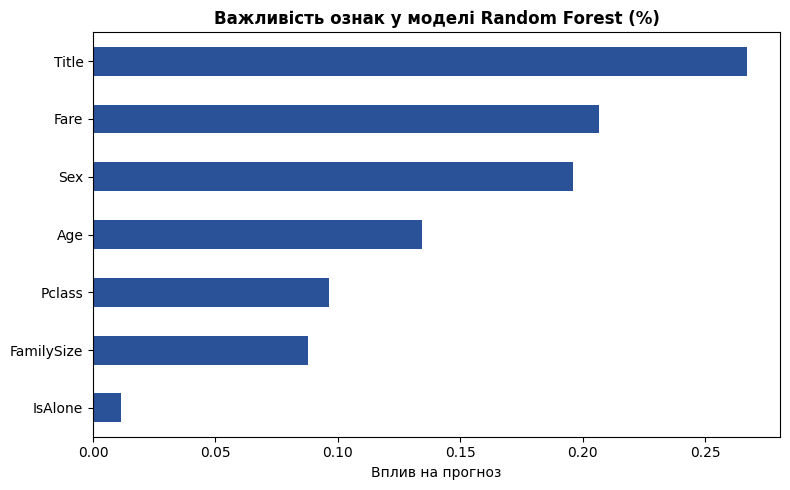

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score

df = pd.read_csv('data/train.csv')
print(f"Розмірність датасету: {df.shape}")
df.head()
df.isnull().sum()
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Fare'] = df['Fare'].fillna(df['Fare'].mean())
df['Sex'] = df['Sex'].map({'female': 1, 'male': 0})
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = np.where(df['FamilySize'] == 1, 1, 0)
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
df['Title'] = df['Title'].map(title_mapping).fillna(0)
features = ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Title']
X = df[features]
y = df['Survived']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
base_model = RandomForestClassifier(class_weight='balanced', random_state=42)

param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 5, 7, 10]
}

grid_search = GridSearchCV(estimator=base_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Найкращі параметри: {grid_search.best_params_}")
print(f"Точність на крос-валідації: {grid_search.best_score_ * 100:.2f}%")

predictions = best_model.predict(X_val)
print(f"Accuracy  (Точність) : {accuracy_score(y_val, predictions) * 100:.2f}%")
print(f"Precision (Влучність): {precision_score(y_val, predictions) * 100:.2f}%")
print(f"Recall    (Повнота)  : {recall_score(y_val, predictions) * 100:.2f}%")

importances = best_model.feature_importances_
feat_importances = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_importances.plot(kind='barh', color='#2a5298')
plt.title('Важливість ознак у моделі Random Forest (%)', fontsize=12, fontweight='bold')
plt.xlabel('Вплив на прогноз')
plt.tight_layout()
plt.show()